# Chapter 3 Engineering Optimization Solutions

---


---


In [1]:
# Solutions Setup
import numpy as np
import matplotlib.pyplot as plt

# Add utilities to path
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from Chapter03_EngineeringOptimization_functions import PlaneStressFEM,TrussFEM


## Truss Problem

In [2]:
def truss7Members(E=200e9, A=0.0005):
    nodes = np.array([
        [0.5, 1.0],   
        [1.5, 1.0],   
        [1.0, 0.0],   
        [0.0, 0.0],   
        [2.0, 0.0],   

    ])

    elements = [
        (0,1),(0,2),(0,3),
        (1,2),(1,4),
        (2,3),(2,4)
    ]

    # Define problem
    fixed_dofs = [6, 7, 8, 9] 
    loads = np.zeros(2 * len(nodes))
    # Calculate direction from node 0 to node 2
    direction = nodes[2] - nodes[0]
    direction = direction / np.linalg.norm(direction)  # Normalize
    print("Direction from node 0 to node 2:", direction)

    # Apply 10kN load in that direction
    loads[2*0] = 10000 * direction[0]
    loads[2*0 + 1] = 10000 * direction[1]
    # Apply 5kN horizontal load at node 1
    loads[2*1] = 5000
    loads[2*1 + 1] = 0

    # Create FEM model
    fem_model = TrussFEM(nodes, elements, loads, fixed_dofs, E=E, A=A)

    return fem_model

Direction from node 0 to node 2: [ 0.4472136  -0.89442719]


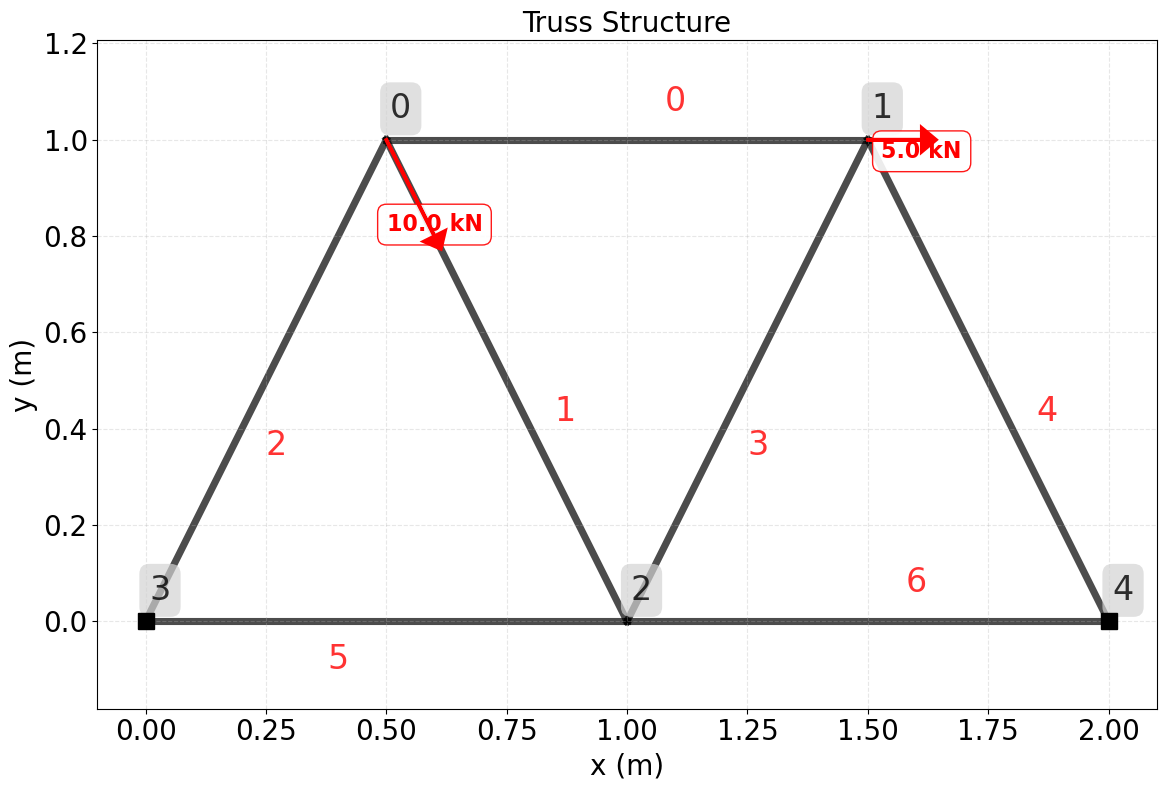

In [3]:
fem_model= truss7Members() 
fem_model.plot_truss(show_labels=True)

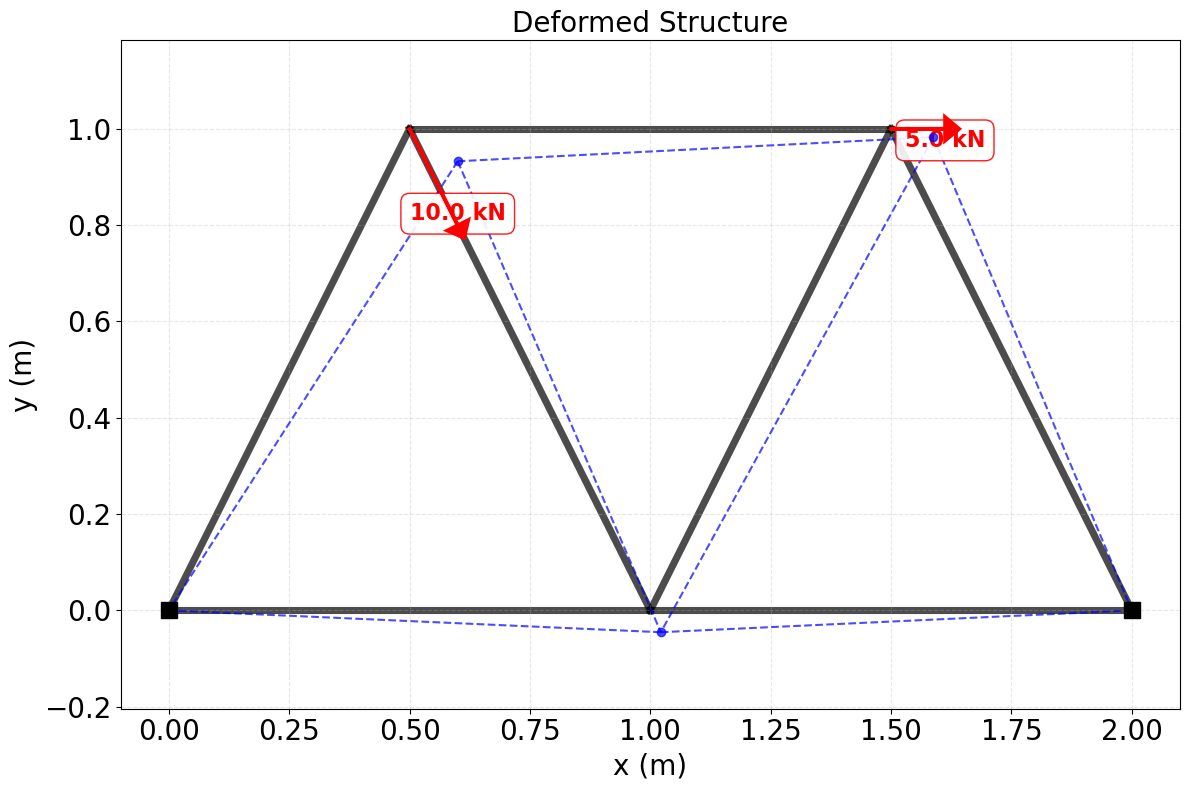

  Volume: 0.00374
  Max displacement: 0.0001924
  Max stress: 1.56e+07
  Compliance: 2.37


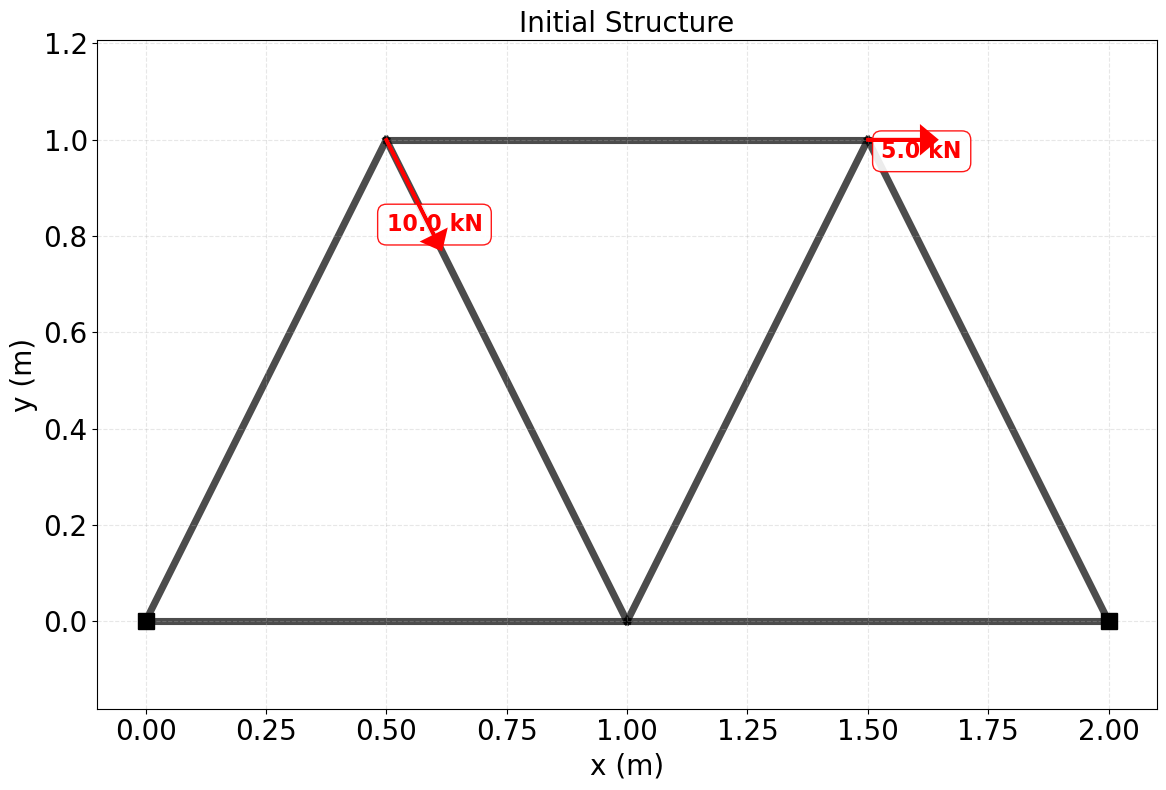

In [4]:
d, valid = fem_model.solve()
# plot deformed truss
fem_model.plot_truss(displacements=d, 
                    title="Deformed Structure")

metrics = fem_model.evaluate_design()
fem_model.print_metrics(metrics)
fem_model.plot_truss(title="Initial Structure")

## Pareto solution

Initial volume: 0.0037 m^3
Starting optimization (Target Volume: 0.1000 fraction)...
 Optimization successful.
Final volume: 0.000374 m^3
Initial volume: 0.0037 m^3
Starting optimization (Target Volume: 0.2000 fraction)...
 Optimization successful.
Final volume: 0.000747 m^3
Initial volume: 0.0037 m^3
Starting optimization (Target Volume: 0.3000 fraction)...
 Optimization successful.
Final volume: 0.00112 m^3
Initial volume: 0.0037 m^3
Starting optimization (Target Volume: 0.4000 fraction)...
 Optimization successful.
Final volume: 0.00149 m^3
Initial volume: 0.0037 m^3
Starting optimization (Target Volume: 0.5000 fraction)...
 Optimization successful.
Final volume: 0.00187 m^3
Initial volume: 0.0037 m^3
Starting optimization (Target Volume: 0.6000 fraction)...
 Optimization successful.
Final volume: 0.00224 m^3
Initial volume: 0.0037 m^3
Starting optimization (Target Volume: 0.7000 fraction)...
 Optimization successful.
Final volume: 0.00262 m^3
Initial volume: 0.0037 m^3
Starting opt

c:\Users\ksure\anaconda3\envs\quantum\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


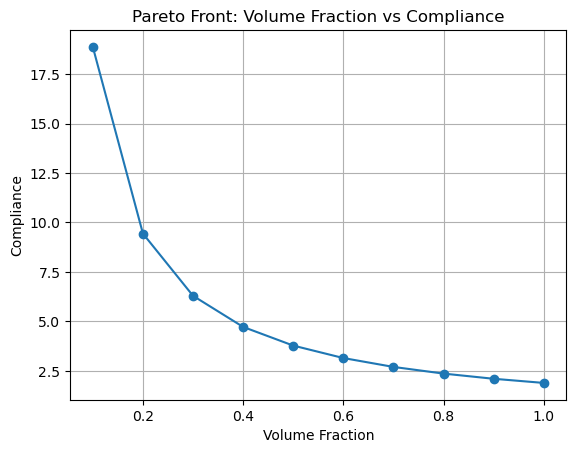

In [5]:
vol_fractions = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9, 1.0]
compliances = []
for vol_frac in vol_fractions:
    result = fem_model.optimize_areas(volume_fraction = vol_frac)
    metrics = fem_model.evaluate_design()
    compliance = metrics['compliance']
    compliances.append(compliance)

plt.plot(vol_fractions, compliances, marker='o')
plt.xlabel('Volume Fraction')
plt.ylabel('Compliance')
plt.title('Pareto Front: Volume Fraction vs Compliance')
plt.grid(True)
plt.show()

## MBB Problem

In [6]:

def PlaneStressMBBBeam(nx=60, ny=10, E= 1e6, nu=0.3):
    """
    MBB (Messerschmitt-Bölkow-Blohm) beam

    
    Fixed bottom-left corner, and bottom-right, load at top-middle
    """
    
    # Create mesh
    lx = nx * (6.0 / 60)
    ly = ny * (1.0 / 10)
    
    fea2D = PlaneStressFEM(nx=nx, ny=ny, lx=lx, ly=ly, E=E, nu=nu)
    
    # Boundary conditions for MBB beam (half model with symmetry)

  
    # Bottom-left corner: fixed support (ux = 0, uy = 0)
    bottom_left_node = 0
    fea2D.apply_boundary_condition([bottom_left_node], dof_x=True, dof_y=True)

    # Bottom-right corner: roller support (ux = free, uy = 0)
    bottom_right_node = fea2D.n_nodes_x - 1
    fea2D.apply_boundary_condition([bottom_right_node], dof_x=False, dof_y=True)

 
    # Load: Downward at top-middle node
    top_middle_node = (fea2D.n_nodes_y - 1) * fea2D.n_nodes_x + (fea2D.n_nodes_x // 2)
    fea2D.apply_force(top_middle_node, fx=0.0, fy=-1.0)
    
    fea2D.title = "Plane Stress MBB Beam"
    return fea2D


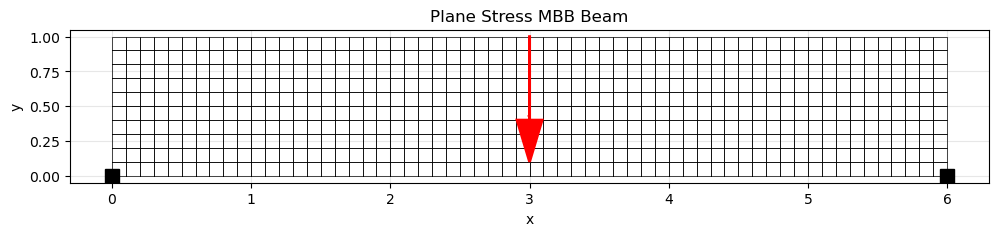

In [7]:
fea2d = PlaneStressMBBBeam(nx=60, ny=10,)
fea2d.plot_mesh()